In [1]:
!pip install kaleido

In [4]:
import pandas as pd
import sqlite3
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Keep our output clean from warnings
warnings.filterwarnings('ignore')

# 1. Setup Environment and Auto-Locate Database
export_dir = Path('exports')
export_dir.mkdir(exist_ok=True)

base_dir = Path.cwd()
db_path = None
search_paths = [
    base_dir / 'bluestock_mf.db',
    base_dir / 'data' / 'bluestock_mf.db',
    base_dir / 'data' / 'db' / 'bluestock_mf.db',
    base_dir.parent / 'bluestock_mf.db',
    base_dir.parent / 'data' / 'bluestock_mf.db',
    base_dir.parent / 'data' / 'db' / 'bluestock_mf.db'
]

for path in search_paths:
    if path.exists():
        db_path = path
        break

if db_path is None:
    raise FileNotFoundError("Could not locate bluestock_mf.db automatically.")

conn = sqlite3.connect(db_path)
print(f"Connected to database at: {db_path}")
print("Generating exact schema visualizations...")

# ---------------------------------------------------------
# CHART 1: NAV Trend Analysis (Plotly)
# ---------------------------------------------------------
df_nav = pd.read_sql("SELECT date, nav FROM fact_nav", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

fig1 = px.line(df_nav, x='date', y='nav', 
               title='Overall Market NAV Trend (2022-2026)',
               labels={'nav': 'Net Asset Value (INR)', 'date': 'Date'})

fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")
fig1.add_vrect(x0="2024-01-01", x1="2024-06-01", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Correction")
fig1.write_image(export_dir / "01_nav_trend.png", width=1200, height=600)
print("-> Chart 1 Generated: NAV Trend")

# ---------------------------------------------------------
# CHART 2: AUM Dominance by Fund House (Seaborn)
# ---------------------------------------------------------
df_aum = pd.read_sql("SELECT fund_house, SUM(aum_cr) as total_aum_cr FROM fact_performance GROUP BY fund_house ORDER BY total_aum_cr DESC", conn)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_aum, x='total_aum_cr', y='fund_house', palette='Blues_r')
plt.title('Asset Under Management (AUM) Dominance by Fund House')
plt.xlabel('Total AUM (in Cr INR)')
plt.ylabel('Fund House')
plt.tight_layout()
plt.savefig(export_dir / "02_aum_dominance.png", dpi=300)
plt.close()
print("-> Chart 2 Generated: AUM Dominance")

# ---------------------------------------------------------
# CHART 3: SIP Inflow Time-Series (Plotly)
# ---------------------------------------------------------
df_sip = pd.read_sql("""
    SELECT strftime('%Y-%m', date) as month, SUM(amount) as total_inflow
    FROM fact_transactions
    WHERE transaction_type = 'Sip'
    GROUP BY month
    ORDER BY month
""", conn)

fig3 = px.bar(df_sip, x='month', y='total_inflow',
              title='Monthly SIP Inflows (2022 - 2025)',
              labels={'total_inflow': 'Total Inflow (INR)', 'month': 'Month'})

max_row = df_sip.loc[df_sip['total_inflow'].idxmax()]
fig3.add_annotation(x=max_row['month'], y=max_row['total_inflow'],
                    text="Peak Inflow Period", showarrow=True, arrowhead=1, yshift=10)
fig3.write_image(export_dir / "03_sip_inflows.png", width=1000, height=500)
print("-> Chart 3 Generated: SIP Inflows Time-Series")

# ---------------------------------------------------------
# CHART 4: Category Inflow Heatmap (Seaborn)
# ---------------------------------------------------------
df_cat = pd.read_sql("""
    SELECT strftime('%Y-%m', t.date) as month, p.category, SUM(t.amount) as net_inflow
    FROM fact_transactions t
    JOIN fact_performance p ON t.amfi_code = p.amfi_code
    GROUP BY month, p.category
""", conn)

pivot_cat = df_cat.pivot(index='category', columns='month', values='net_inflow').fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_cat, cmap='YlGnBu', linewidths=0.5)
plt.title('Net Inflows by Asset Category Map')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(export_dir / "04_category_heatmap.png", dpi=300)
plt.close()
print("-> Chart 4 Generated: Category Inflow Heatmap")

# ---------------------------------------------------------
# CHART 5A: Investor Age Demographics (Matplotlib)
# ---------------------------------------------------------
df_dem = pd.read_sql("SELECT age_group, gender, amount FROM fact_transactions WHERE transaction_type = 'Sip'", conn)

plt.figure(figsize=(8, 6))
age_counts = df_dem['age_group'].value_counts()
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Investor Age Group Distribution')
plt.tight_layout()
plt.savefig(export_dir / "05a_investor_age.png", dpi=300)
plt.close()
print("-> Chart 5A Generated: Age Distribution")

# ---------------------------------------------------------
# CHART 5B: Investor Gender Demographics (Matplotlib)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
gender_counts = df_dem['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
plt.title('Investor Gender Profile Split')
plt.tight_layout()
plt.savefig(export_dir / "05b_investor_gender.png", dpi=300)
plt.close()
print("-> Chart 5B Generated: Gender Distribution")

print("\nAll structured charts generated successfully without errors.")
conn.close()

Connected to database at: C:\Users\csmri\OneDrive\Desktop\mutual_fund_project\data\db\bluestock_mf.db
Generating exact schema visualizations...
-> Chart 1 Generated: NAV Trend
-> Chart 2 Generated: AUM Dominance
-> Chart 3 Generated: SIP Inflows Time-Series
-> Chart 4 Generated: Category Inflow Heatmap
-> Chart 5A Generated: Age Distribution
-> Chart 5B Generated: Gender Distribution

All structured charts generated successfully without errors.


Loading saved charts...
------------------------------

Viewing: 01_nav_trend.png


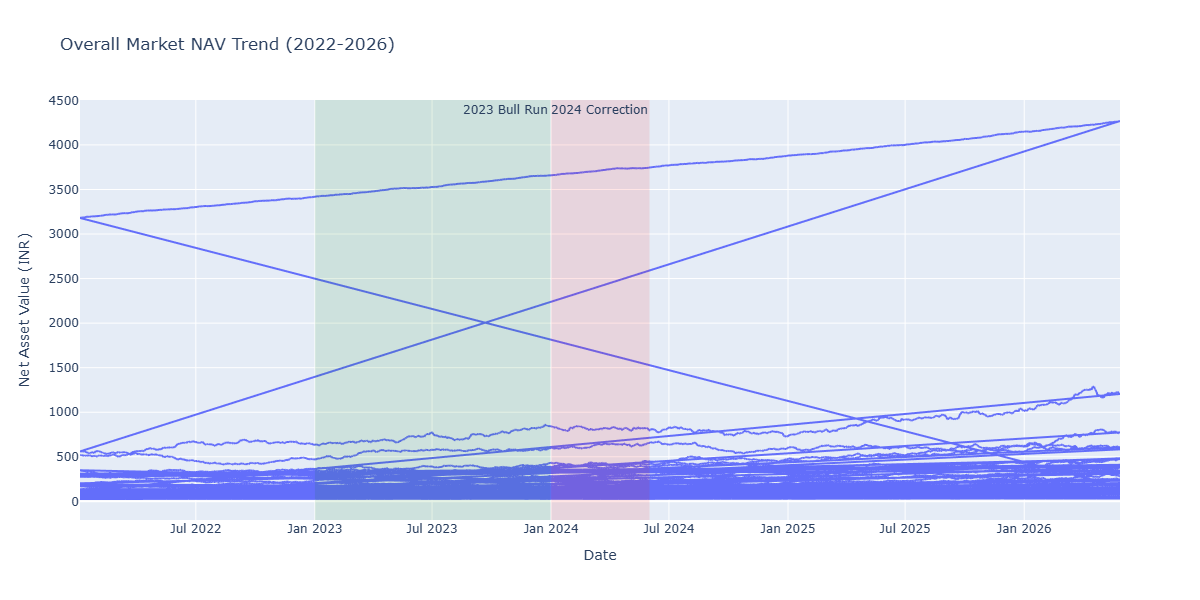


Viewing: 02_aum_dominance.png


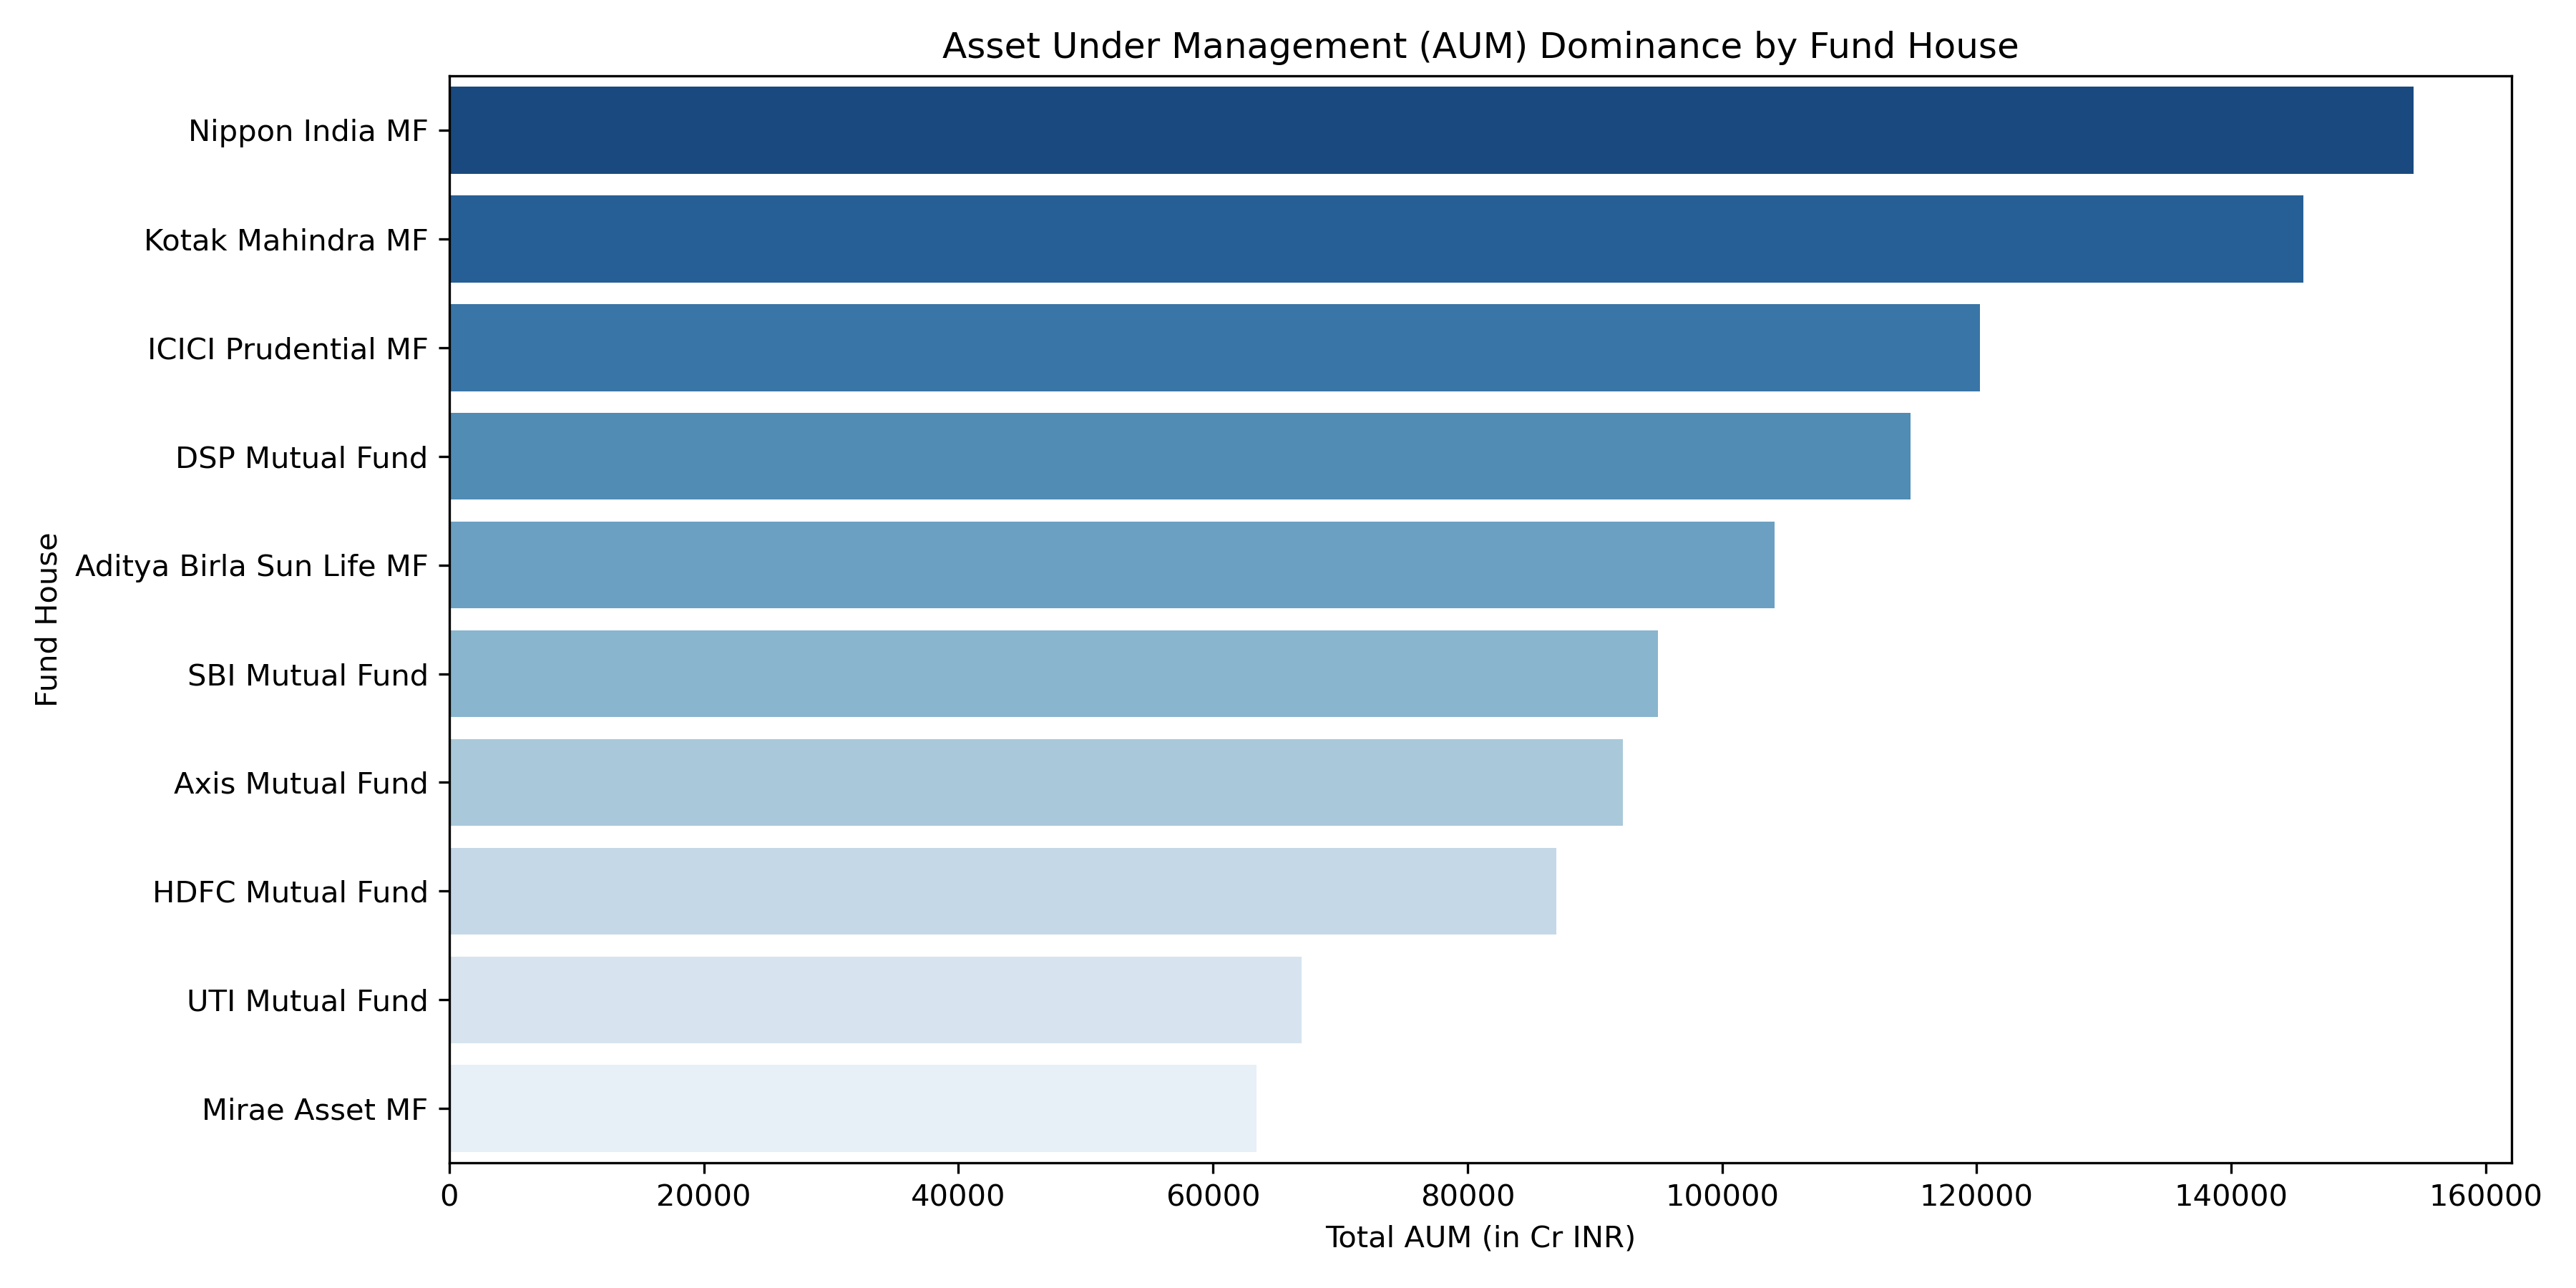


Viewing: 03_sip_inflows.png


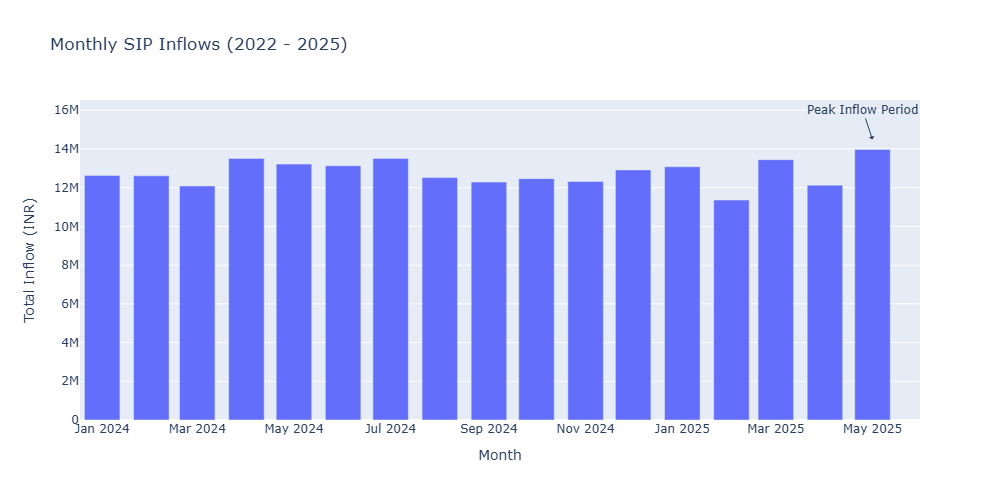


Viewing: 04_category_heatmap.png


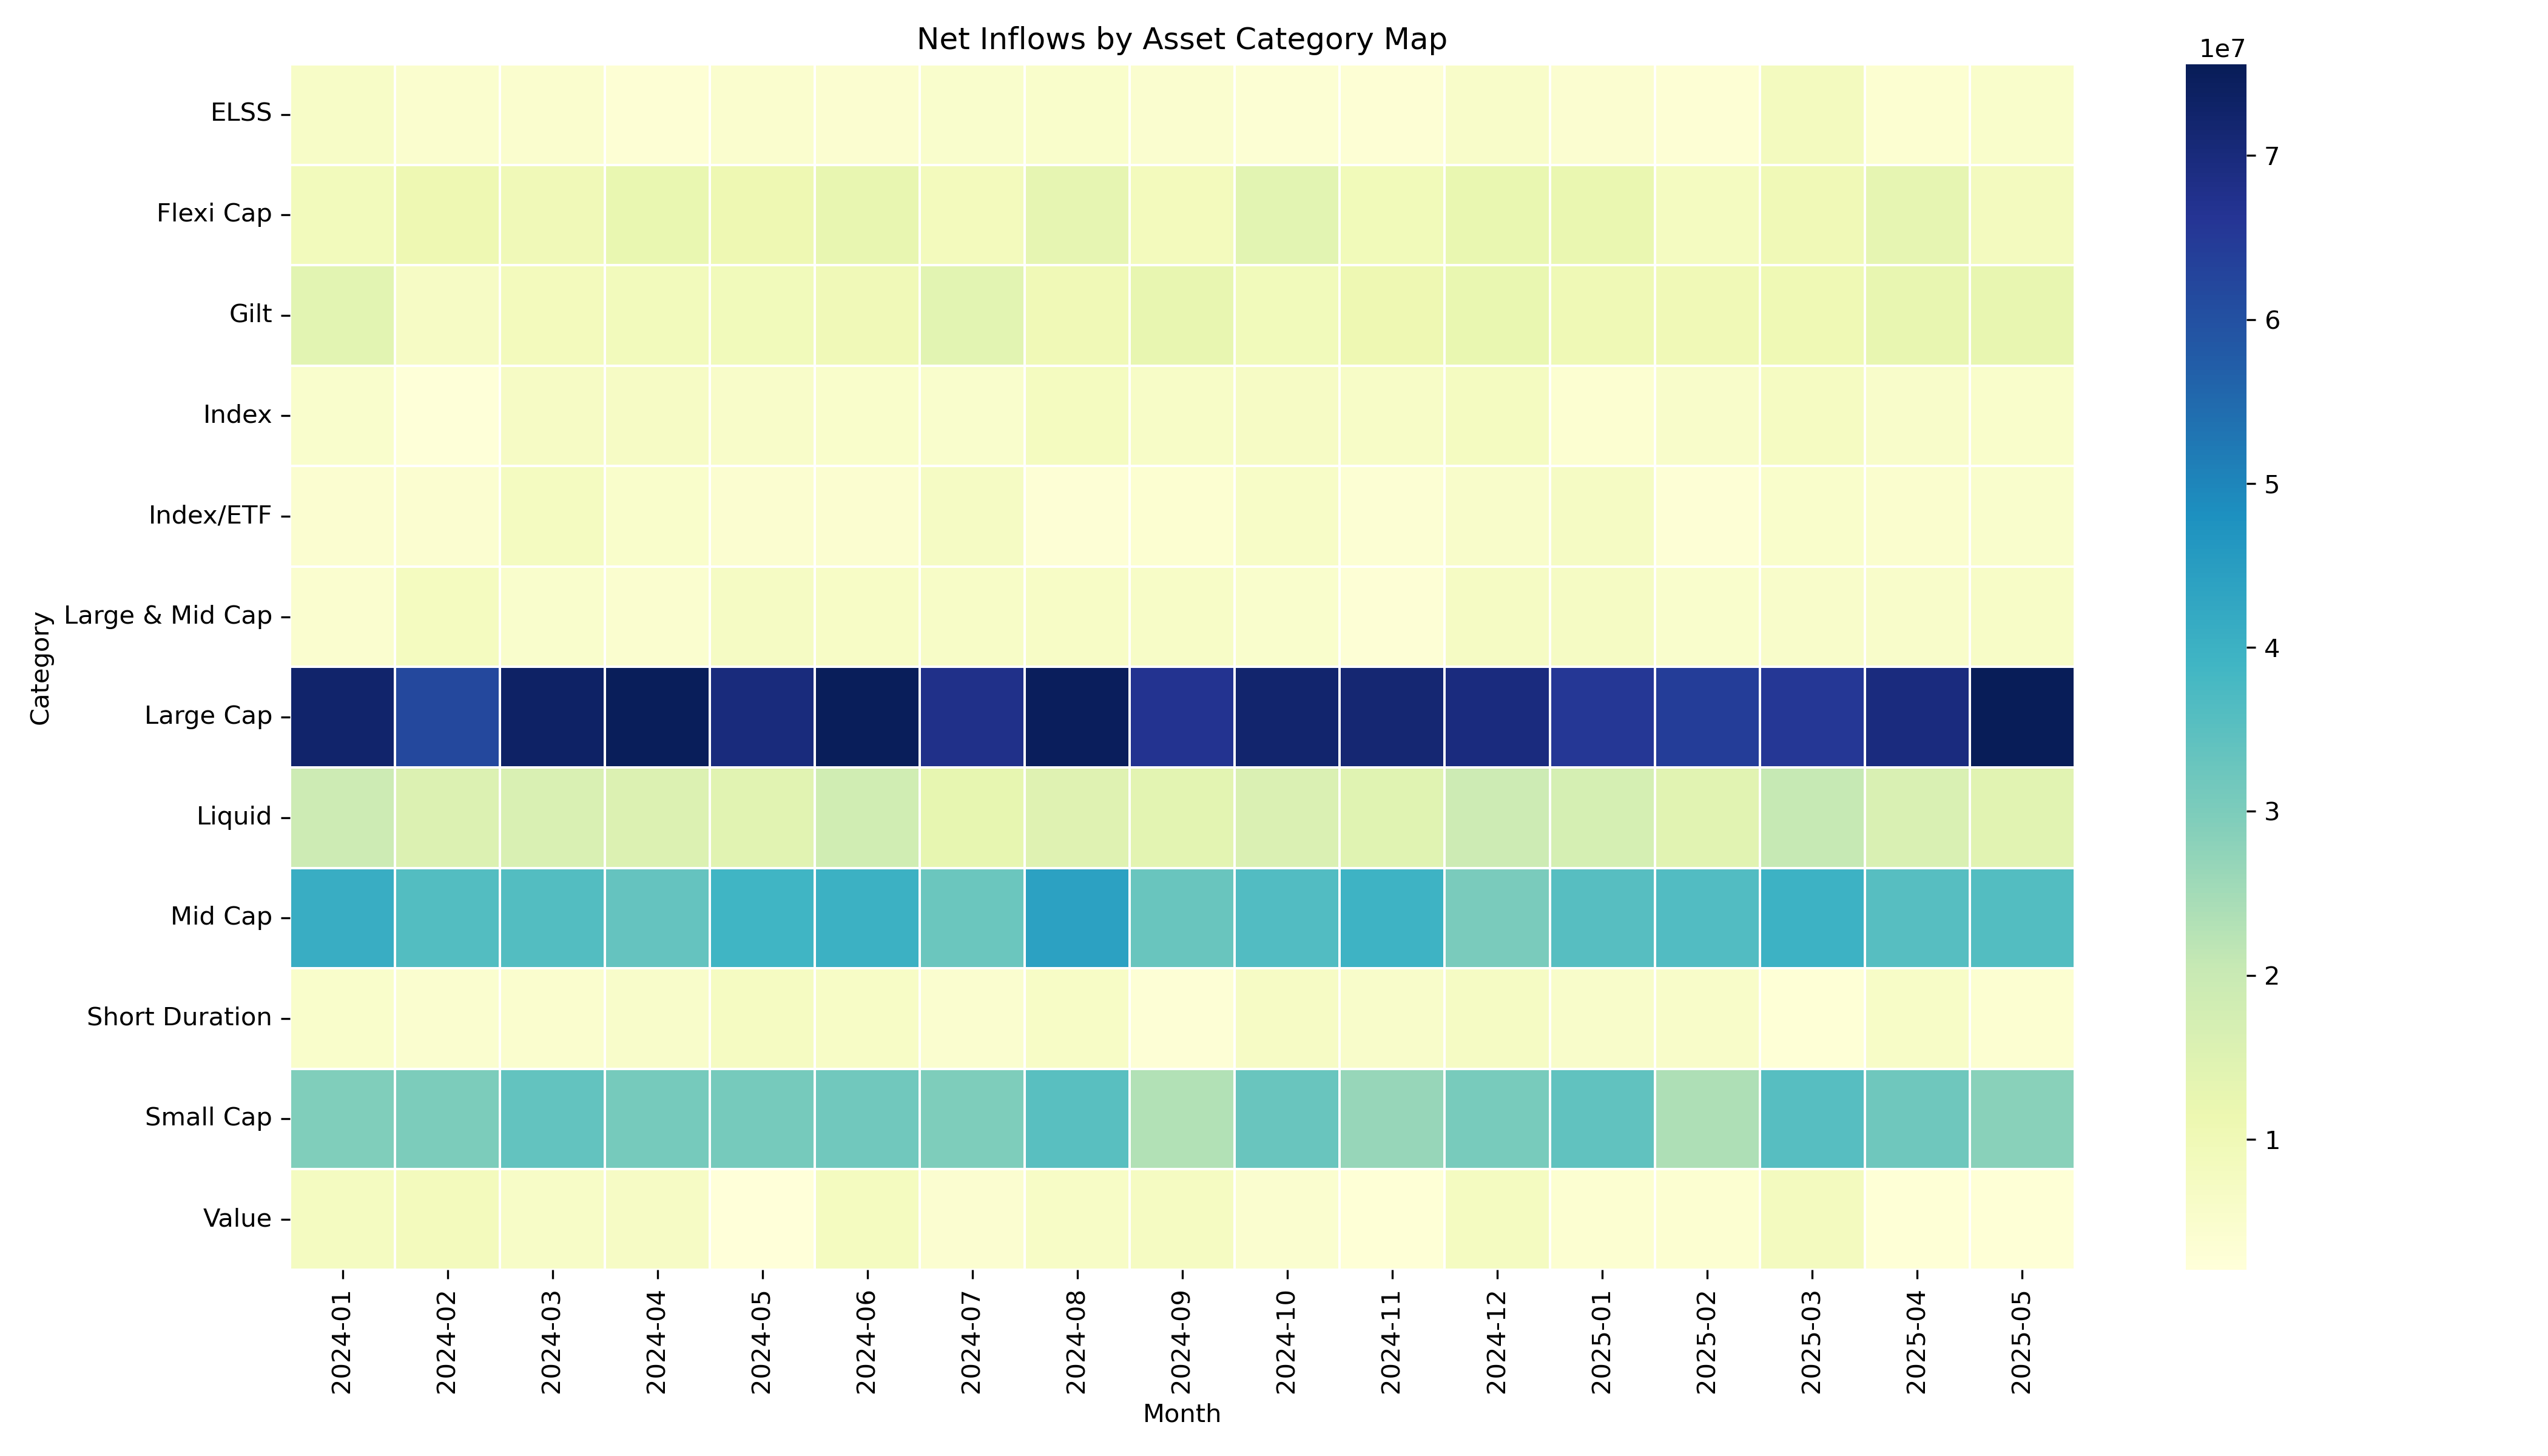


Viewing: 05a_investor_age.png


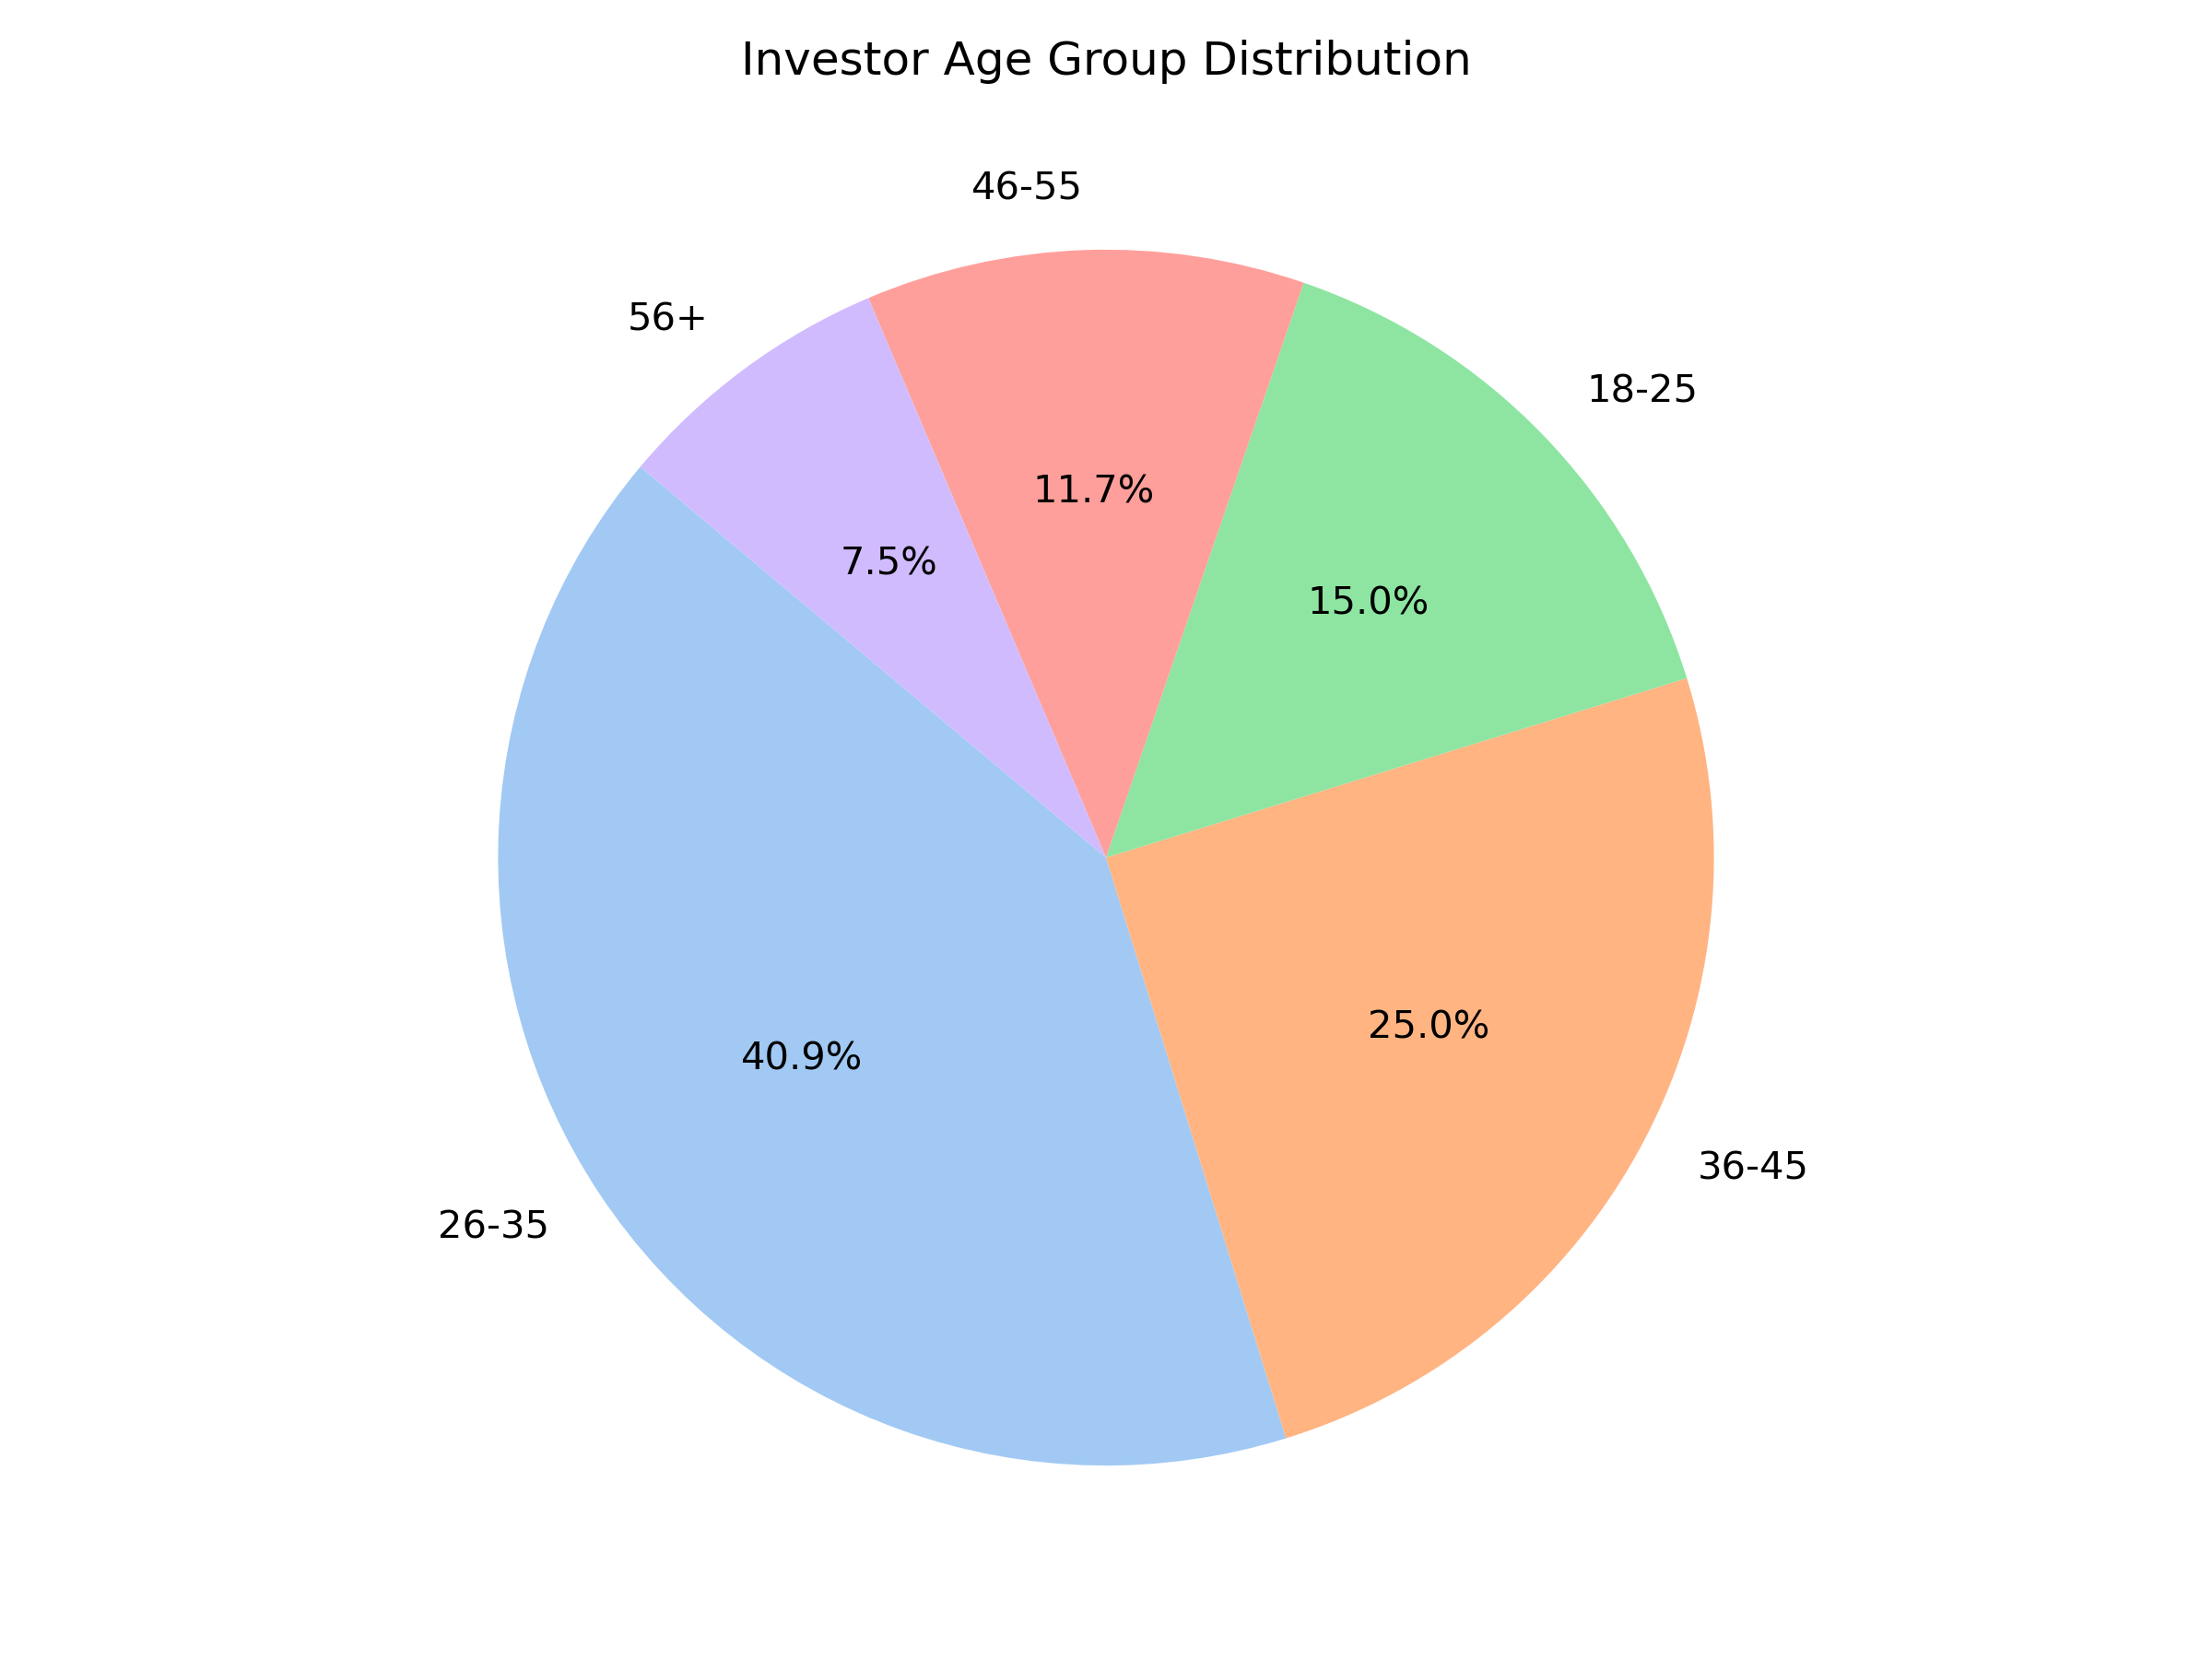


Viewing: 05b_investor_gender.png


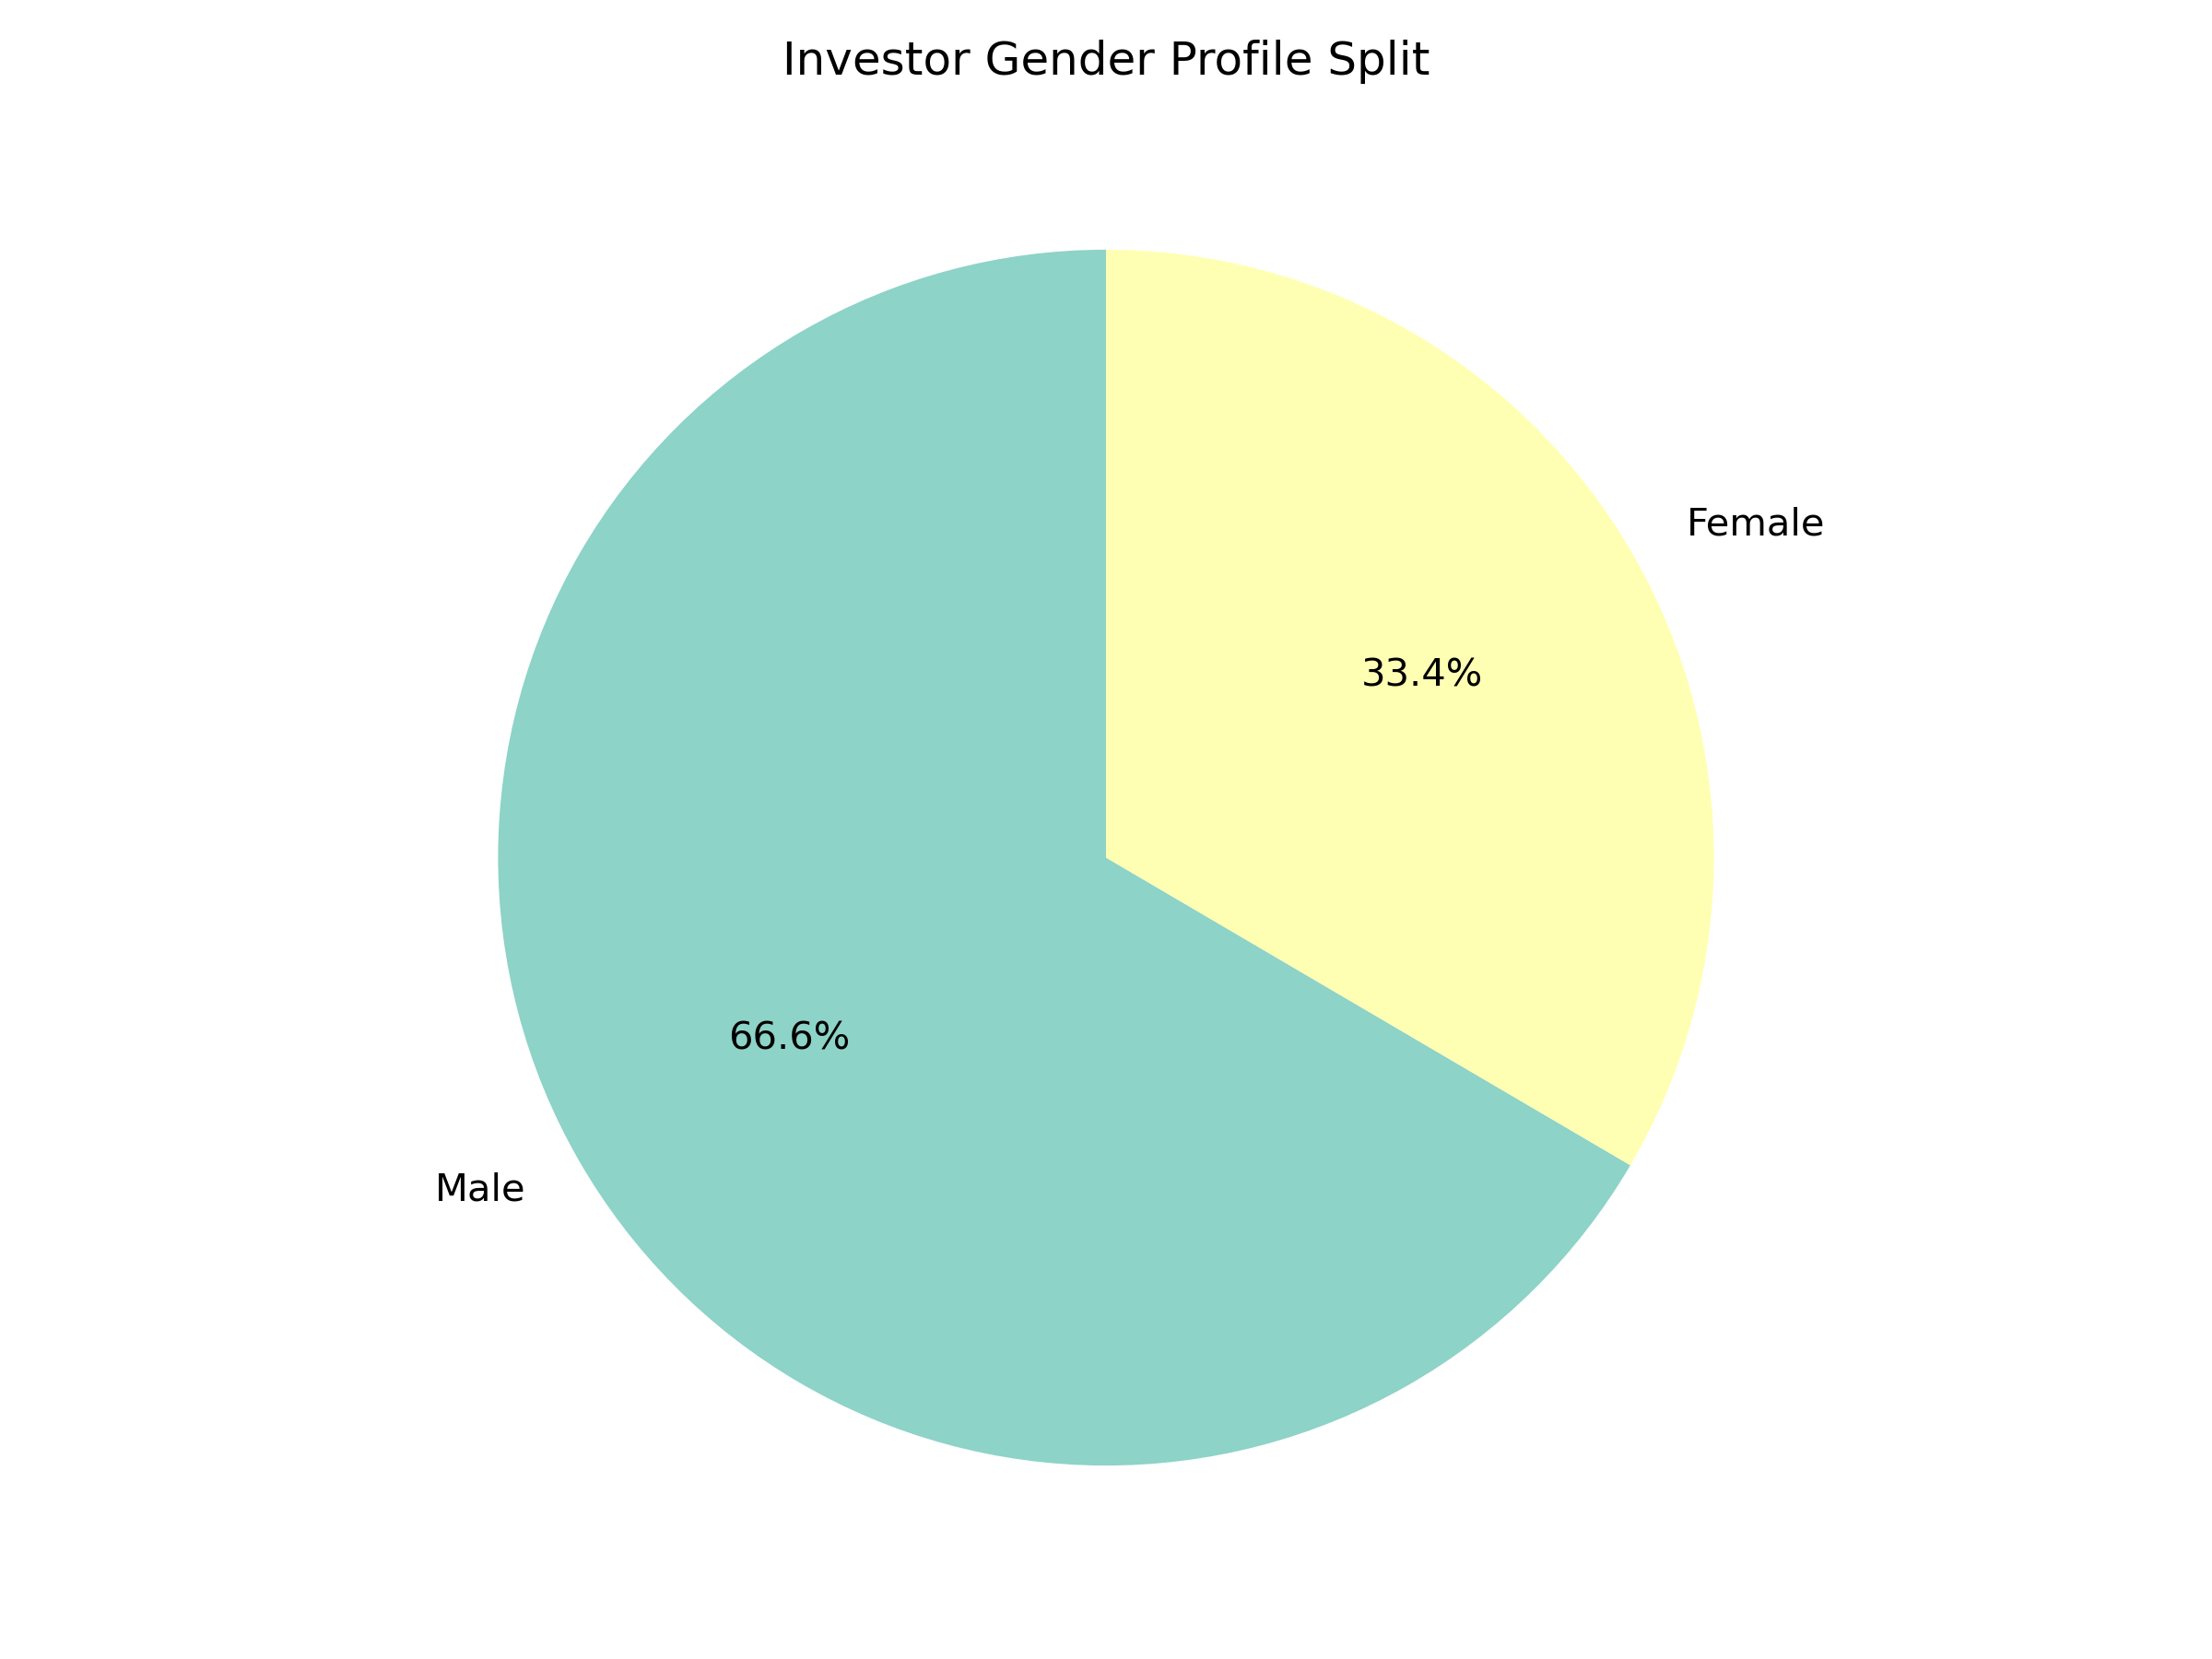

In [5]:
from IPython.display import Image, display
from pathlib import Path

export_dir = Path('exports')
print("Loading saved charts...\n" + "-"*30)

for img_file in sorted(export_dir.glob('*.png')):
    print(f"\nViewing: {img_file.name}")
    display(Image(filename=img_file))

In [6]:
import pandas as pd
from pathlib import Path

# Locate the processed data folder
processed_dir = Path.cwd() / 'data' / 'processed'
if not processed_dir.exists():
    processed_dir = Path.cwd().parent / 'data' / 'processed'

files_to_check = ['06_industry_folio_count.csv', '09_portfolio_holdings.csv']

print("--- Checking CSV Columns ---")
for file in files_to_check:
    file_path = processed_dir / file
    if file_path.exists():
        cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        print(f"{file}:\n{cols}\n")
    else:
        print(f"Could not find {file}\n")

--- Checking CSV Columns ---
06_industry_folio_count.csv:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

09_portfolio_holdings.csv:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']



In [7]:
import pandas as pd
import sqlite3
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

export_dir = Path('exports')
processed_dir = Path.cwd() / 'data' / 'processed'

# Connect to database for the transaction queries
base_dir = Path.cwd()
db_path = None
search_paths = [
    base_dir / 'bluestock_mf.db',
    base_dir / 'data' / 'bluestock_mf.db',
    base_dir / 'data' / 'db' / 'bluestock_mf.db'
]
for path in search_paths:
    if path.exists():
        db_path = path
        break

conn = sqlite3.connect(db_path)
print("Generating final batch of visualizations...")

# ---------------------------------------------------------
# CHART 6: Geographic T30 vs B30 (Plotly Pie)
# ---------------------------------------------------------
df_tier = pd.read_sql("""
    SELECT city_tier, SUM(amount) as total_amount 
    FROM fact_transactions 
    WHERE transaction_type = 'Sip' 
    GROUP BY city_tier
""", conn)

fig6 = px.pie(df_tier, values='total_amount', names='city_tier', 
              title='SIP Volume Distribution: T30 vs B30 Cities')
fig6.write_image(export_dir / "06_city_tier.png", width=800, height=500)
print("-> Chart 6 Generated: T30 vs B30 Cities")

# ---------------------------------------------------------
# CHART 7: SIP Amount by Age Group (Seaborn Bar Chart)
# ---------------------------------------------------------
df_age_amt = pd.read_sql("""
    SELECT age_group, AVG(amount) as avg_amount 
    FROM fact_transactions 
    WHERE transaction_type = 'Sip' 
    GROUP BY age_group
""", conn)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_age_amt, x='age_group', y='avg_amount', palette='Set2')
plt.title('Average SIP Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average SIP Amount (INR)')
plt.tight_layout()
plt.savefig(export_dir / "07_age_amount.png", dpi=300)
plt.close()
print("-> Chart 7 Generated: Average SIP by Age Group")

# ---------------------------------------------------------
# CHART 8: Folio Count Growth (Plotly Line)
# ---------------------------------------------------------
df_folio = pd.read_csv(processed_dir / '06_industry_folio_count.csv')
fig8 = px.line(df_folio, x='month', y='total_folios_crore', 
               title='Industry Folio Count Growth (2022 - 2025)',
               labels={'total_folios_crore': 'Total Folios (in Crores)', 'month': 'Month'})
fig8.write_image(export_dir / "08_folio_growth.png", width=1000, height=500)
print("-> Chart 8 Generated: Folio Count Growth")

# ---------------------------------------------------------
# CHART 9: Sector Allocation Donut (Plotly)
# ---------------------------------------------------------
df_sector = pd.read_csv(processed_dir / '09_portfolio_holdings.csv')
df_sector_grp = df_sector.groupby('sector')['weight_pct'].sum().reset_index()

fig9 = px.pie(df_sector_grp, values='weight_pct', names='sector', hole=0.4, 
              title='Overall Sector Allocation across Equity Funds')
fig9.update_traces(textposition='inside', textinfo='percent+label')
fig9.write_image(export_dir / "09_sector_donut.png", width=900, height=600)
print("-> Chart 9 Generated: Sector Allocation Donut")

# ---------------------------------------------------------
# CHART 10: NAV Return Correlation Heatmap (Seaborn)
# ---------------------------------------------------------
# Pulling directly from CSV to ensure we have amfi_code mapped to daily nav
df_nav_raw = pd.read_csv(processed_dir / 'cleaned_nav_history.csv')
df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])

# Select top 10 funds to keep the matrix readable
top_funds = df_nav_raw['amfi_code'].unique()[:10]
df_nav_filtered = df_nav_raw[df_nav_raw['amfi_code'].isin(top_funds)]

# Pivot to get dates on index and funds as columns
pivot_nav = df_nav_filtered.pivot(index='date', columns='amfi_code', values='nav')

# Calculate correlation of daily changes
corr_matrix = pivot_nav.pct_change().corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Daily Return Correlation Matrix (Top 10 Funds)')
plt.tight_layout()
plt.savefig(export_dir / "10_nav_correlation.png", dpi=300)
plt.close()
print("-> Chart 10 Generated: NAV Correlation Matrix")

print("\nAll remaining charts successfully saved to the 'exports' folder.")
conn.close()

Generating final batch of visualizations...
-> Chart 6 Generated: T30 vs B30 Cities
-> Chart 7 Generated: Average SIP by Age Group
-> Chart 8 Generated: Folio Count Growth
-> Chart 9 Generated: Sector Allocation Donut


KeyError: 'amfi_code'

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

export_dir = Path('exports')
export_dir.mkdir(exist_ok=True)

# Point directly to the raw data folder to bypass the missing column issue
raw_dir = Path.cwd() / 'data' / 'raw'
if not raw_dir.exists():
    raw_dir = Path.cwd().parent / 'data' / 'raw'

print("Generating Chart 10 (Correlation Matrix) from raw data...")

# Read the RAW file instead of the processed one
df_nav_raw = pd.read_csv(raw_dir / '02_nav_history.csv')

# Instantly clean the columns on the fly
df_nav_raw.columns = df_nav_raw.columns.str.strip().str.lower()
df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])

# Select top 10 unique funds
top_funds = df_nav_raw['amfi_code'].unique()[:10]
df_nav_filtered = df_nav_raw[df_nav_raw['amfi_code'].isin(top_funds)]

# Pivot to get dates on index and funds as columns
pivot_nav = df_nav_filtered.pivot(index='date', columns='amfi_code', values='nav')

# Calculate correlation of daily percentage changes
corr_matrix = pivot_nav.pct_change().corr()

# Generate the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Daily Return Correlation Matrix (Top 10 Funds)')
plt.tight_layout()
plt.savefig(export_dir / "10_nav_correlation.png", dpi=300)
plt.close()

print("✅ Chart 10 Generated: NAV Correlation Matrix!")

Generating Chart 10 (Correlation Matrix) from raw data...
✅ Chart 10 Generated: NAV Correlation Matrix!


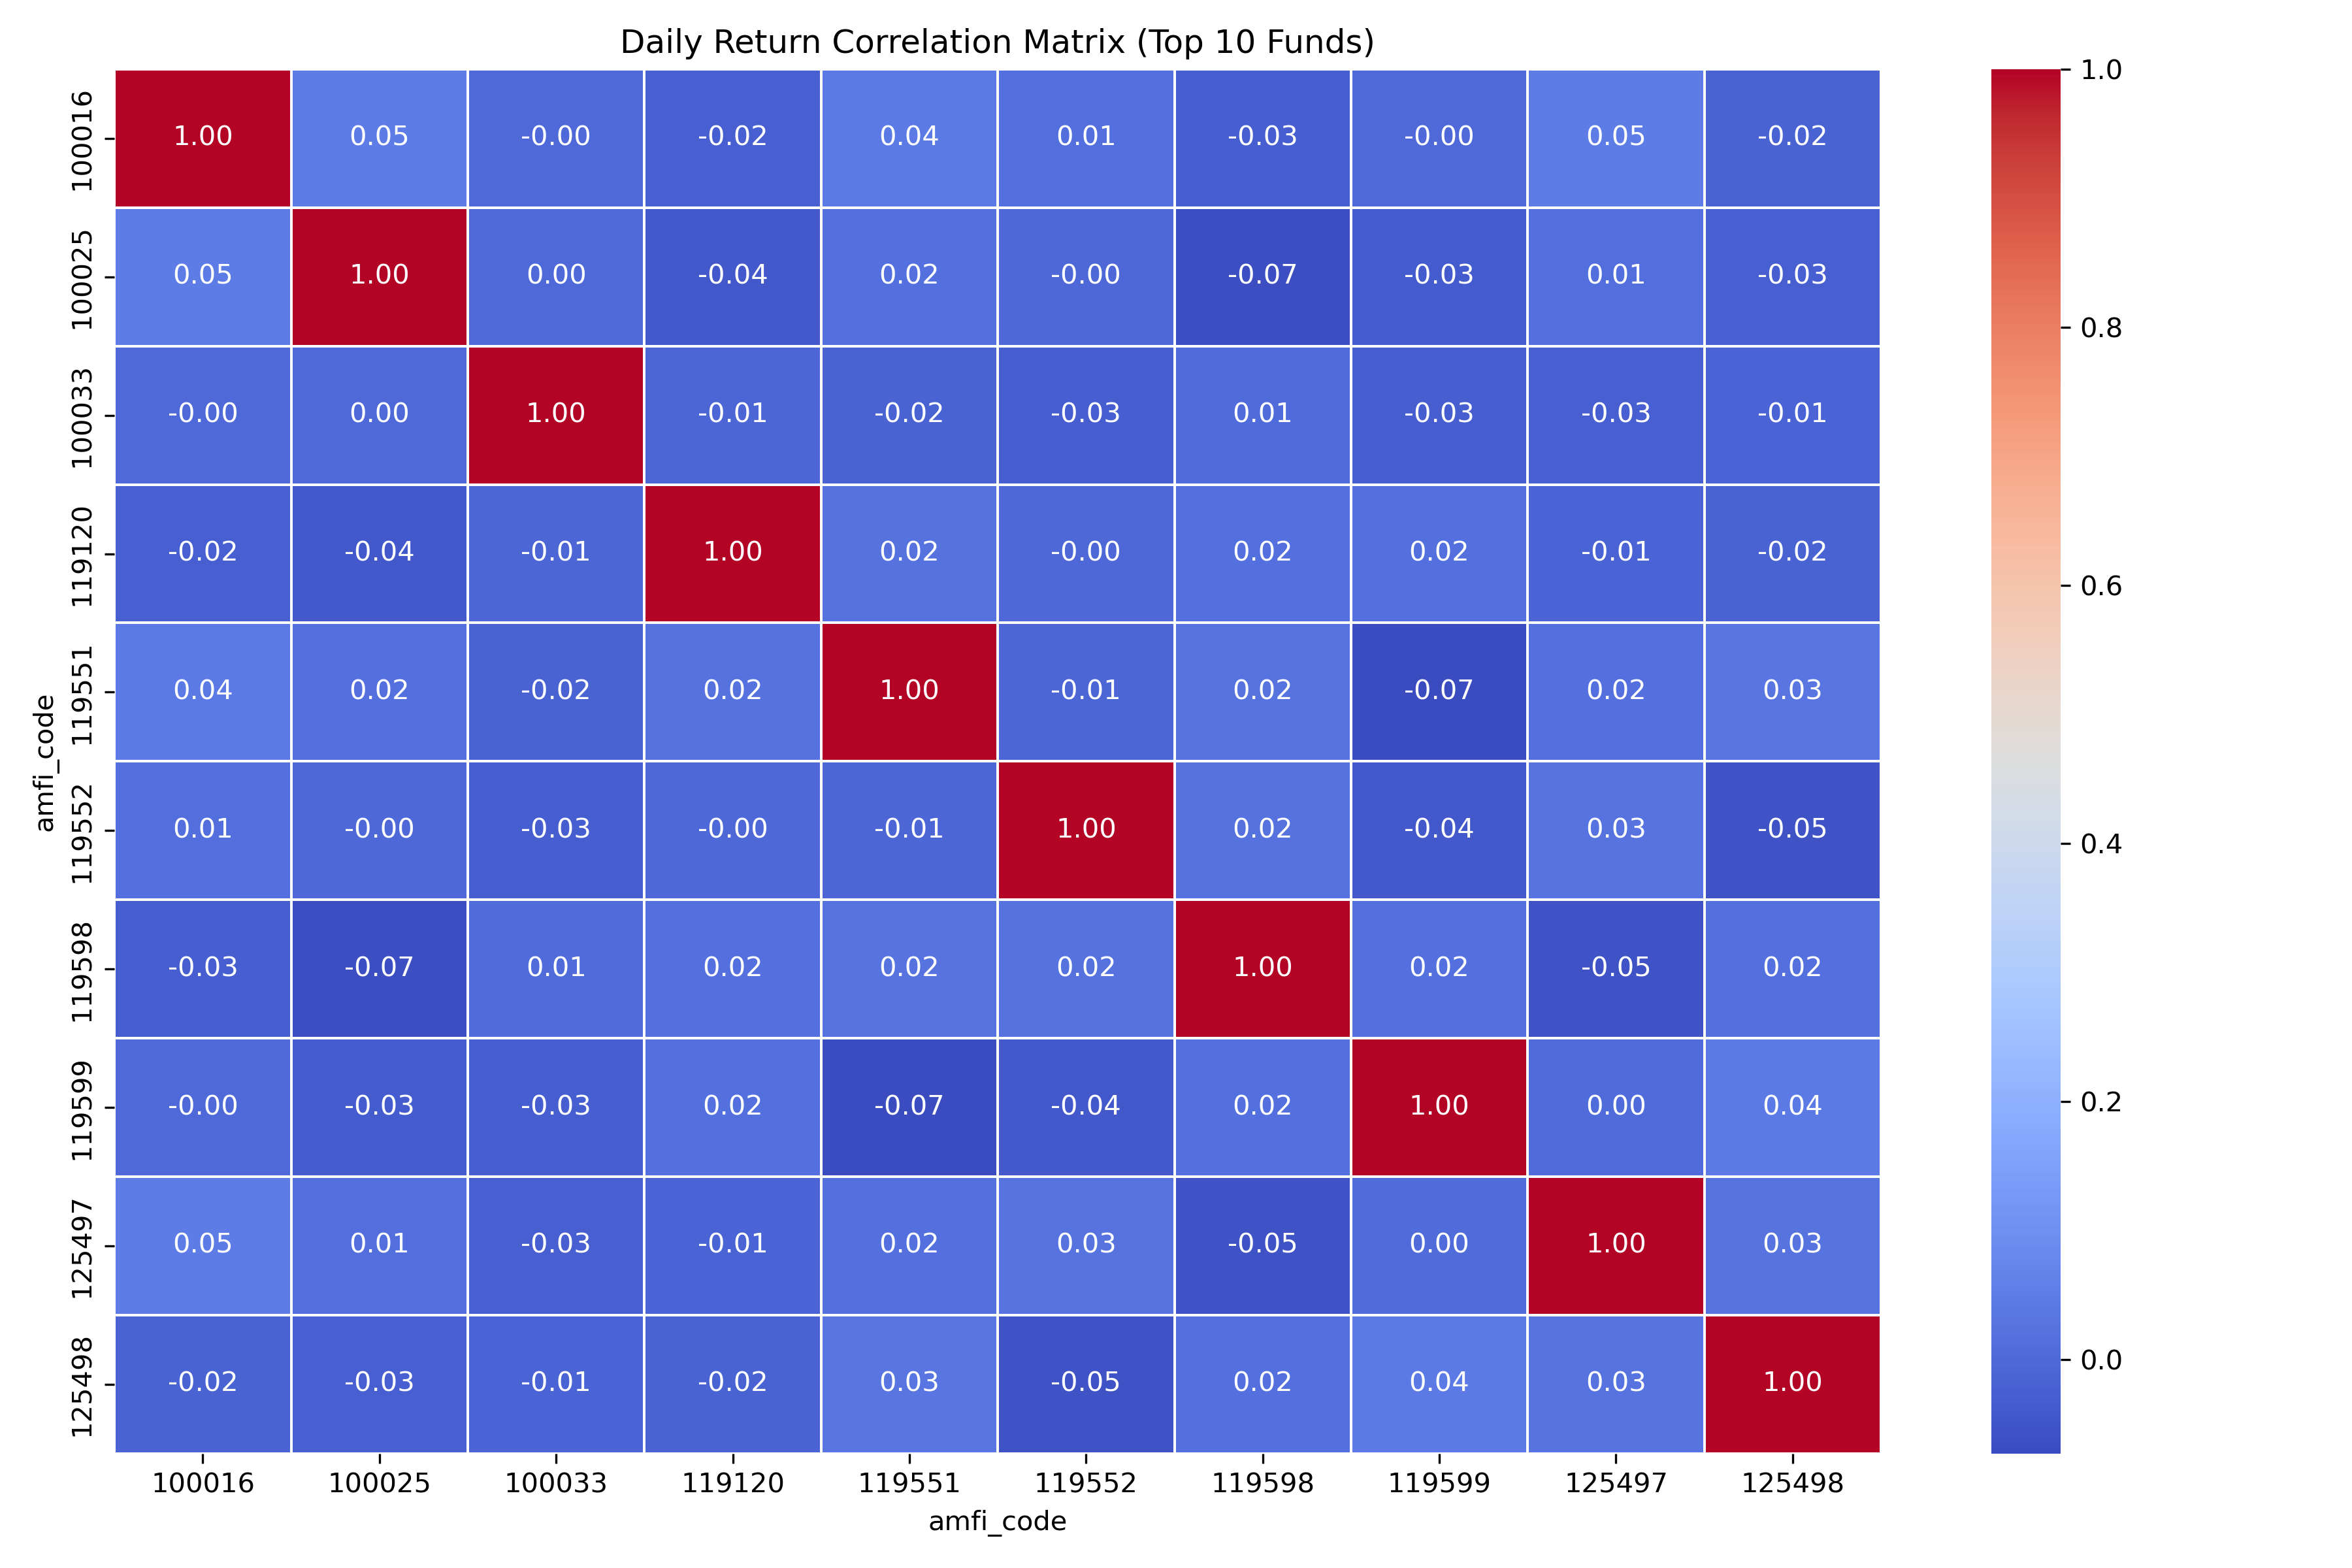

In [9]:
from IPython.display import Image, display
from pathlib import Path

# Point to your newly generated matrix image
img_path = Path('exports') / '10_nav_correlation.png'

# Display it right here in the notebook
display(Image(filename=img_path))

In [10]:
import os
from pathlib import Path

print("--- FINAL REPOSITORY AUDIT ---")
base_dir = Path.cwd()
if base_dir.name != 'mutual_fund_project':
    base_dir = base_dir.parent

# 1. Check Notebooks
print("\n1. Notebooks:")
notebooks = list((base_dir / 'notebooks').glob('*.ipynb'))
for f in notebooks:
    print(f" - {f.name}")

# 2. Check Exported Charts
print("\n2. Exported Charts:")
exports = list((base_dir / 'exports').glob('*.png'))
for f in sorted(exports):
    print(f" - {f.name}")
print(f" Total Charts Found: {len(exports)}")

# 3. Check Scripts
print("\n3. Scripts:")
scripts = list((base_dir / 'scripts').glob('*.py'))
for f in scripts:
    print(f" - {f.name}")
    
print("\nAudit Complete. Please verify the lists above.")

--- FINAL REPOSITORY AUDIT ---

1. Notebooks:
 - 00_data_check.ipynb

2. Exported Charts:
 - 01_nav_trend.png
 - 02_aum_dominance.png
 - 03_sip_inflows.png
 - 04_category_heatmap.png
 - 05a_investor_age.png
 - 05b_investor_gender.png
 - 06_city_tier.png
 - 07_age_amount.png
 - 08_folio_growth.png
 - 09_sector_donut.png
 - 10_nav_correlation.png
 Total Charts Found: 11

3. Scripts:
 - data_ingestion.py
 - etl_pipeline.py
 - live_nav_fetch.py

Audit Complete. Please verify the lists above.
